In [1]:
import numpy as np
import pandas as pd
import requests
import time 

In [2]:
url = "https://api.worldbank.org/countries?format=json&per_page=300"
response = requests.get(url)
response.status_code
if response.headers.get("Content-Type", "").startswith("application/json"):
    data = response.json()
else:
    print("not in json format")
    print(response.text)

In [3]:
data = response.json()
data[0]

{'page': 1, 'pages': 1, 'per_page': '300', 'total': 296}

In [4]:
countries = pd.DataFrame(data[1])

In [5]:
countries

,id,iso2Code,name,region,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,AW,Aruba,"{'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Lati...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'HIC', 'iso2code': 'XD', 'value': 'High...","{'id': 'LNX', 'iso2code': 'XX', 'value': 'Not ...",Oranjestad,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
2,AFG,AF,Afghanistan,"{'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Midd...","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...","{'id': 'LIC', 'iso2code': 'XM', 'value': 'Low ...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Kabul,69.1761,34.5228
3,AFR,A9,Africa,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
4,AFW,ZI,Africa Western and Central,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
...,...,...,...,...,...,...,...,...,...,...
291,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
292,YEM,YE,"Yemen, Rep.","{'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Midd...","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...","{'id': 'LIC', 'iso2code': 'XM', 'value': 'Low ...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Sana'a,44.2075,15.352
293,ZAF,ZA,South Africa,"{'id': 'SSF', 'iso2code': 'ZG', 'value': 'Sub-...","{'id': 'SSA', 'iso2code': 'ZF', 'value': 'Sub-...","{'id': 'UMC', 'iso2code': 'XT', 'value': 'Uppe...","{'id': 'IBD', 'iso2code': 'XF', 'value': 'IBRD'}",Pretoria,28.1871,-25.746
294,ZMB,ZM,Zambia,"{'id': 'SSF', 'iso2code': 'ZG', 'value': 'Sub-...","{'id': 'SSA', 'iso2code': 'ZF', 'value': 'Sub-...","{'id': 'LMC', 'iso2code': 'XN', 'value': 'Lowe...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Lusaka,28.2937,-15.3982


In [6]:
countries["region"]= countries["region"].apply(lambda x:x["value"])

In [7]:
countries["incomeLevel"] = countries["incomeLevel"].apply(lambda x:x["value"])

In [8]:
countries["lendingType"] = countries["lendingType"].apply(lambda x:x["value"])
countries 

,id,iso2Code,name,region,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,"{'id': '', 'iso2code': '', 'value': ''}",High income,Not classified,Oranjestad,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,"{'id': '', 'iso2code': '', 'value': ''}",Aggregates,Aggregates,,,
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...",Low income,IDA,Kabul,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,"{'id': '', 'iso2code': '', 'value': ''}",Aggregates,Aggregates,,,
4,AFW,ZI,Africa Western and Central,Aggregates,"{'id': '', 'iso2code': '', 'value': ''}",Aggregates,Aggregates,,,
...,...,...,...,...,...,...,...,...,...,...
291,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,Aggregates,"{'id': '', 'iso2code': '', 'value': ''}",Aggregates,Aggregates,,,
292,YEM,YE,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...",Low income,IDA,Sana'a,44.2075,15.352
293,ZAF,ZA,South Africa,Sub-Saharan Africa,"{'id': 'SSA', 'iso2code': 'ZF', 'value': 'Sub-...",Upper middle income,IBRD,Pretoria,28.1871,-25.746
294,ZMB,ZM,Zambia,Sub-Saharan Africa,"{'id': 'SSA', 'iso2code': 'ZF', 'value': 'Sub-...",Lower middle income,IDA,Lusaka,28.2937,-15.3982


In [9]:
countries.drop(columns = ["adminregion", "capitalCity"], inplace= True)
countries

,id,iso2Code,name,region,incomeLevel,lendingType,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,High income,Not classified,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,Aggregates,Aggregates,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...
291,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,Aggregates,Aggregates,Aggregates,,
292,YEM,YE,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,44.2075,15.352
293,ZAF,ZA,South Africa,Sub-Saharan Africa,Upper middle income,IBRD,28.1871,-25.746
294,ZMB,ZM,Zambia,Sub-Saharan Africa,Lower middle income,IDA,28.2937,-15.3982


In [10]:
countries = countries.rename(columns={"iso2Code":"country_id"})

In [11]:
countries

,id,country_id,name,region,incomeLevel,lendingType,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,High income,Not classified,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,Aggregates,Aggregates,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...
291,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,Aggregates,Aggregates,Aggregates,,
292,YEM,YE,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,44.2075,15.352
293,ZAF,ZA,South Africa,Sub-Saharan Africa,Upper middle income,IBRD,28.1871,-25.746
294,ZMB,ZM,Zambia,Sub-Saharan Africa,Lower middle income,IDA,28.2937,-15.3982


In [81]:
countries[countries["region"]== "Aggregates"]

,id,country_id,name,region,incomeLevel,lendingType,longitude,latitude
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
3,AFR,A9,Africa,Aggregates,Aggregates,Aggregates,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,Aggregates,,
8,ARB,1A,Arab World,Aggregates,Aggregates,Aggregates,,
18,BEA,B4,East Asia & Pacific (IBRD-only countries),Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...
269,TSA,T5,South Asia (IDA & IBRD),Aggregates,Aggregates,Aggregates,,
270,TSS,T6,Sub-Saharan Africa (IDA & IBRD countries),Aggregates,Aggregates,Aggregates,,
278,UMC,XT,Upper middle income,Aggregates,Aggregates,Aggregates,,
288,WLD,1W,World,Aggregates,Aggregates,Aggregates,,


In [15]:
# url for Indicators

base_url = "https://api.worldbank.org/v2/indicators?format=json"
response = requests.get(base_url)
response.status_code
response.headers.get("Content-Type")

'application/json;charset=utf-8'

In [16]:
indicator_data = response.json()
records=indicator_data[1]
keys=['id', 'name']

[
    {k:indicator.get(k) for k in keys}
    for indicator in records
]

[{'id': '1.0.HCount.1.90usd', 'name': 'Poverty Headcount ($1.90 a day)'},
 {'id': '1.0.HCount.2.5usd', 'name': 'Poverty Headcount ($2.50 a day)'},
 {'id': '1.0.HCount.Mid10to50',
  'name': 'Middle Class ($10-50 a day) Headcount'},
 {'id': '1.0.HCount.Ofcl', 'name': 'Official Moderate Poverty Rate-National'},
 {'id': '1.0.HCount.Poor4uds', 'name': 'Poverty Headcount ($4 a day)'},
 {'id': '1.0.HCount.Vul4to10', 'name': 'Vulnerable ($4-10 a day) Headcount'},
 {'id': '1.0.PGap.1.90usd', 'name': 'Poverty Gap ($1.90 a day)'},
 {'id': '1.0.PGap.2.5usd', 'name': 'Poverty Gap ($2.50 a day)'},
 {'id': '1.0.PGap.Poor4uds', 'name': 'Poverty Gap ($4 a day)'},
 {'id': '1.0.PSev.1.90usd', 'name': 'Poverty Severity ($1.90 a day)'},
 {'id': '1.0.PSev.2.5usd', 'name': 'Poverty Severity ($2.50 a day)'},
 {'id': '1.0.PSev.Poor4uds', 'name': 'Poverty Severity ($4 a day)'},
 {'id': '1.1.HCount.1.90usd', 'name': 'Poverty Headcount ($1.90 a day)-Rural'},
 {'id': '1.1.HCount.2.5usd', 'name': 'Poverty Headcount

In [17]:
indicator_data[0].keys()

dict_keys(['page', 'pages', 'per_page', 'total'])

In [18]:
pages = indicator_data[0]["pages"]

all_df=[]
for i in range(1, pages):
    url = f"https://api.worldbank.org/v2/indicators?format=json&per_page=500&page={i}"
    response =requests.get(url)

    if response.status_code != 200:
        print(f"failed to fetch the page{i}, Response code: {response.status_code}")
        continue
    data=response.json()

    if  not isinstance(data, list)or len(data)<2 or not data[1]:
        print(f"No data found in page{i}")
        break    
    df = data[1]
    page_df=pd.DataFrame(
             [{"id":d["id"],
              "name":d["name"]}
             ] for d in df
             )
    all_df.append(page_df)
    print(f"Pages{i}: {len(df)} Indicators Collected")

Pages1: 500 Indicators Collected
Pages2: 500 Indicators Collected
Pages3: 500 Indicators Collected
Pages4: 500 Indicators Collected
Pages5: 500 Indicators Collected
Pages6: 500 Indicators Collected
Pages7: 500 Indicators Collected
Pages8: 500 Indicators Collected
Pages9: 500 Indicators Collected
Pages10: 500 Indicators Collected
Pages11: 500 Indicators Collected
Pages12: 500 Indicators Collected
Pages13: 500 Indicators Collected
Pages14: 500 Indicators Collected
Pages15: 500 Indicators Collected
Pages16: 500 Indicators Collected
Pages17: 500 Indicators Collected
Pages18: 500 Indicators Collected
Pages19: 500 Indicators Collected
Pages20: 500 Indicators Collected
Pages21: 500 Indicators Collected
Pages22: 500 Indicators Collected
Pages23: 500 Indicators Collected
Pages24: 500 Indicators Collected
Pages25: 500 Indicators Collected
Pages26: 500 Indicators Collected
Pages27: 500 Indicators Collected
Pages28: 500 Indicators Collected
Pages29: 500 Indicators Collected
Pages30: 500 Indicators

In [20]:
final_df = pd.concat(all_df, ignore_index=True)

In [21]:
final_df = pd.json_normalize(final_df[0])

In [22]:
final_df

,id,name
0,1.0.HCount.1.90usd,Poverty Headcount ($1.90 a day)
1,1.0.HCount.2.5usd,Poverty Headcount ($2.50 a day)
2,1.0.HCount.Mid10to50,Middle Class ($10-50 a day) Headcount
3,1.0.HCount.Ofcl,Official Moderate Poverty Rate-National
4,1.0.HCount.Poor4uds,Poverty Headcount ($4 a day)
...,...,...
29318,ytil_some_dfcl_all,Youth idle rate (% of persons with some degree...
29319,ytil_some_dfcl_fem,Youth idle rate (% of female persons with some...
29320,ytil_some_dfcl_male,Youth idle rate (% of male persons with some d...
29321,ytil_some_dfcl_rur,Youth idle rate (% of persons living in rural ...


In [23]:
indicator_groups = {
"economic_activity_growth": [
"NY.GDP.MKTP.KD.ZG", # GDP growth (annual %)
"NY.GDP.PCAP.CD" # GDP per capita (current US$)
],
"labour_market_indicators": [
"SL.UEM.TOTL.ZS", # Unemployment total
"SL.UEM.1524.ZS", # Unemployment youth total (ages 15–24)
"SL.TLF.TOTL.IN" # Labour force, total
],
"trade_globalization": [
"NE.EXP.GNFS.CD", # Exports of goods and services (current US$)
"NE.IMP.GNFS.CD" # Imports of goods and services (current US$)
],
"poverty_inequality": [
"SI.POV.NAHC", # Poverty headcount ratio at national poverty lines (% of population)
"SI.POV.GINI" # Gini index (measure of income inequality)
],
"environmental_indicators": [
"EG.FEC.RNEW.ZS", # Renewable energy consumption (% of total final energy consumption)
"AG.LND.FRST.ZS" # Forest area (% of land area)
],
"health_indicators": [
"SP.DYN.LE00.IN", # Life expectancy at birth
"SP.DYN.IMRT.IN", # Infant mortality rate
"SH.H2O.BASW.ZS", # Access to at least basic water services (% of population)
"SH.XPD.CHEX.GD.ZS", # Current health expenditure (% of GDP)
"SH.IMM.IDPT", # Immunization, DPT (% of children ages 12–23 months)
"SH.IMM.MEAS", # Immunization, measles (% of children ages 12–23 months)
"SH.MMR.RISK.ZS", # Risk of maternal death
"SH.DTH.COMM.ZS", # Deaths from communicable diseases (% of total)
"SH.TBS.INCD", # Tuberculosis incidence (per 100,000 people)
"SH.STA.BRTC.ZS", # Births attended by skilled health staff (%)
"SH.STA.MMRT", # Maternal mortality ratio (modeled estimate, per 100,000 live births)
"SP.POP.65UP.TO.ZS", # Population ages 65 and above (% of total population)
"SH.HIV.INCD.ZS" # HIV incidence rate (per 1,000 uninfected population ages 15–49)
],
"technology_indicators": [
"IT.NET.USER.ZS", # Individuals using the Internet (% of population)
"IT.CEL.SETS.P2" # Mobile cellular subscriptions (per 100 people)
]
}

In [28]:
for i , j in indicator_groups.items():
    print(i)
    print(j)
    print("")
    

economic_activity_growth
['NY.GDP.MKTP.KD.ZG', 'NY.GDP.PCAP.CD']

labour_market_indicators
['SL.UEM.TOTL.ZS', 'SL.UEM.1524.ZS', 'SL.TLF.TOTL.IN']

trade_globalization
['NE.EXP.GNFS.CD', 'NE.IMP.GNFS.CD']

poverty_inequality
['SI.POV.NAHC', 'SI.POV.GINI']

environmental_indicators
['EG.FEC.RNEW.ZS', 'AG.LND.FRST.ZS']

health_indicators
['SP.DYN.LE00.IN', 'SP.DYN.IMRT.IN', 'SH.H2O.BASW.ZS', 'SH.XPD.CHEX.GD.ZS', 'SH.IMM.IDPT', 'SH.IMM.MEAS', 'SH.MMR.RISK.ZS', 'SH.DTH.COMM.ZS', 'SH.TBS.INCD', 'SH.STA.BRTC.ZS', 'SH.STA.MMRT', 'SP.POP.65UP.TO.ZS', 'SH.HIV.INCD.ZS']

technology_indicators
['IT.NET.USER.ZS', 'IT.CEL.SETS.P2']



In [25]:
base_url = "https://api.worldbank.org/countries/all/indicators/{}?format=json&per_page=1000&page={}"
category_dataframe={}

for category, indicators in indicator_groups.items():
    print(f"Fetching information for Category{category}")
    all_df=[]
    for indicator in indicators:
        print(f"Fetching indicator:{indicator}")
        page = 1
        while True:
            url= base_url.format(indicator, page)

            response = requests.get(url)
            if response.status_code!=200:
                print(f"HTTP error {response.status_code} for indicator {indicator} on page {page}")
                break
            
            try:
                data = response.json()
            except ValueError:
                print(f"Invalid JSON for {indicator} on page {page}. Breaking loop.")
                break
            if not data or len(data)<2 or not data[1]:
                break

            total_pages= data[0]["pages"]
            df = pd.json_normalize(data[1])
            df = df.rename(columns={
                "indicator.id":"indicator_id",
                "indicator.value":"indicators",
                "country.id":"country_id",
                "country.value":"country",
                "date":"year"
            })

            df["year"] = pd.to_numeric(df["year"], errors= "coerce")
            df = df[df["year"]>2015]

            if not df.empty:
                all_df.append(df)

            if page > total_pages:
                break
            else:
                page+=1
                time.sleep(0.2)
           
    if all_df:
         combined_df = pd.concat(all_df, ignore_index=True)
         category_dataframe[category]=combined_df
         print(f"Total rows  collected for {category}:{len(combined_df)}")
    else:
         print(f"No data collected for {category}")


print("Data Fetching completed")

Fetching information for Categoryeconomic_activity_growth
Fetching indicator:NY.GDP.MKTP.KD.ZG
Fetching indicator:NY.GDP.PCAP.CD
Total rows  collected for economic_activity_growth:4788
Fetching information for Categorylabour_market_indicators
Fetching indicator:SL.UEM.TOTL.ZS
Fetching indicator:SL.UEM.1524.ZS
Fetching indicator:SL.TLF.TOTL.IN
Total rows  collected for labour_market_indicators:7182
Fetching information for Categorytrade_globalization
Fetching indicator:NE.EXP.GNFS.CD
Fetching indicator:NE.IMP.GNFS.CD
Total rows  collected for trade_globalization:4788
Fetching information for Categorypoverty_inequality
Fetching indicator:SI.POV.NAHC
Fetching indicator:SI.POV.GINI
Total rows  collected for poverty_inequality:4788
Fetching information for Categoryenvironmental_indicators
Fetching indicator:EG.FEC.RNEW.ZS
HTTP error 400 for indicator EG.FEC.RNEW.ZS on page 17
Fetching indicator:AG.LND.FRST.ZS
Total rows  collected for environmental_indicators:4617
Fetching information for C

In [26]:
economic_activity= category_dataframe.get("economic_activity_growth", pd.DataFrame())
labour_market_jobs= category_dataframe.get("labour_market_indicators", pd.DataFrame())
trade_globalization= category_dataframe.get("trade_globalization", pd.DataFrame())
poverty_inequality= category_dataframe.get("poverty_inequality", pd.DataFrame())
environmental_indicators= category_dataframe.get("environmental_indicators", pd.DataFrame())
health_indicators= category_dataframe.get("health_indicators", pd.DataFrame())
technology_indicators= category_dataframe.get("technology_indicators", pd.DataFrame())

In [27]:
trade_globalization

,countryiso3code,year,value,unit,obs_status,decimal,indicator_id,indicators,country_id,country
0,AFE,2024,3.198254e+11,,,0,NE.EXP.GNFS.CD,Exports of goods and services (current US$),ZH,Africa Eastern and Southern
1,AFE,2023,3.084462e+11,,,0,NE.EXP.GNFS.CD,Exports of goods and services (current US$),ZH,Africa Eastern and Southern
2,AFE,2022,3.334846e+11,,,0,NE.EXP.GNFS.CD,Exports of goods and services (current US$),ZH,Africa Eastern and Southern
3,AFE,2021,2.880277e+11,,,0,NE.EXP.GNFS.CD,Exports of goods and services (current US$),ZH,Africa Eastern and Southern
4,AFE,2020,2.095170e+11,,,0,NE.EXP.GNFS.CD,Exports of goods and services (current US$),ZH,Africa Eastern and Southern
...,...,...,...,...,...,...,...,...,...,...
4783,ZWE,2020,6.794920e+09,,,0,NE.IMP.GNFS.CD,Imports of goods and services (current US$),ZW,Zimbabwe
4784,ZWE,2019,7.784812e+09,,,0,NE.IMP.GNFS.CD,Imports of goods and services (current US$),ZW,Zimbabwe
4785,ZWE,2018,9.691544e+09,,,0,NE.IMP.GNFS.CD,Imports of goods and services (current US$),ZW,Zimbabwe
4786,ZWE,2017,1.549960e+10,,,0,NE.IMP.GNFS.CD,Imports of goods and services (current US$),ZW,Zimbabwe


In [28]:
economic = pd.merge(economic_activity, countries, on = "country_id", how= "inner")
labour_market = pd.merge(labour_market_jobs, countries, on ="country_id", how="inner")
trade= pd.merge(trade_globalization, countries, on ="country_id", how="inner")
poverty= pd.merge(poverty_inequality, countries, on ="country_id", how="inner")
environment= pd.merge(environmental_indicators, countries, on ="country_id", how="inner")
health=pd.merge(health_indicators, countries, on ="country_id", how="inner")
technology=pd.merge(technology_indicators, countries, on ="country_id", how="inner")

In [29]:
economic.drop(columns=["indicator_id","name","id"], inplace=True)
trade.drop(columns=["indicator_id","name","id"], inplace=True)
labour_market.drop(columns=["indicator_id","name","id"], inplace=True)
poverty.drop(columns=["indicator_id","name","id"], inplace=True)
environment.drop(columns=["indicator_id","name","id"], inplace=True)
health.drop(columns=["indicator_id","name","id"], inplace=True)
technology.drop(columns=["indicator_id","name","id"], inplace=True)

In [30]:
health

,countryiso3code,year,value,unit,obs_status,decimal,indicators,country_id,country,region,incomeLevel,lendingType,longitude,latitude
0,AFE,2024,NaN,,,0,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
1,AFE,2023,65.146154,,,0,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
2,AFE,2022,64.487020,,,0,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
3,AFE,2021,62.979999,,,0,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
4,AFE,2020,63.766484,,,0,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29835,ZWE,2020,1.900000,,,1,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",ZW,Zimbabwe,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
29836,ZWE,2019,2.300000,,,1,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",ZW,Zimbabwe,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
29837,ZWE,2018,2.700000,,,1,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",ZW,Zimbabwe,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
29838,ZWE,2017,3.600000,,,1,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",ZW,Zimbabwe,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312


In [43]:
economic.to_csv("D:/Power_Bi/Live_dashboard/economic.csv")

In [44]:
trade.to_csv("D:/Power_Bi/Live_dashboard/trade.csv")
labour_market.to_csv("D:/Power_Bi/Live_dashboard/labor_market.csv")
poverty.to_csv("D:/Power_Bi/Live_dashboard/poverty.csv")
environment.to_csv("D:/Power_Bi/Live_dashboard/enviornment.csv")
health.to_csv("D:/Power_Bi/Live_dashboard/health.csv")
technology.to_csv("D:/Power_Bi/Live_dashboard/technology.csv")

In [33]:
df_wide = health.pivot(index=["country", "year"],
                       columns="indicators",
                       values= "value")

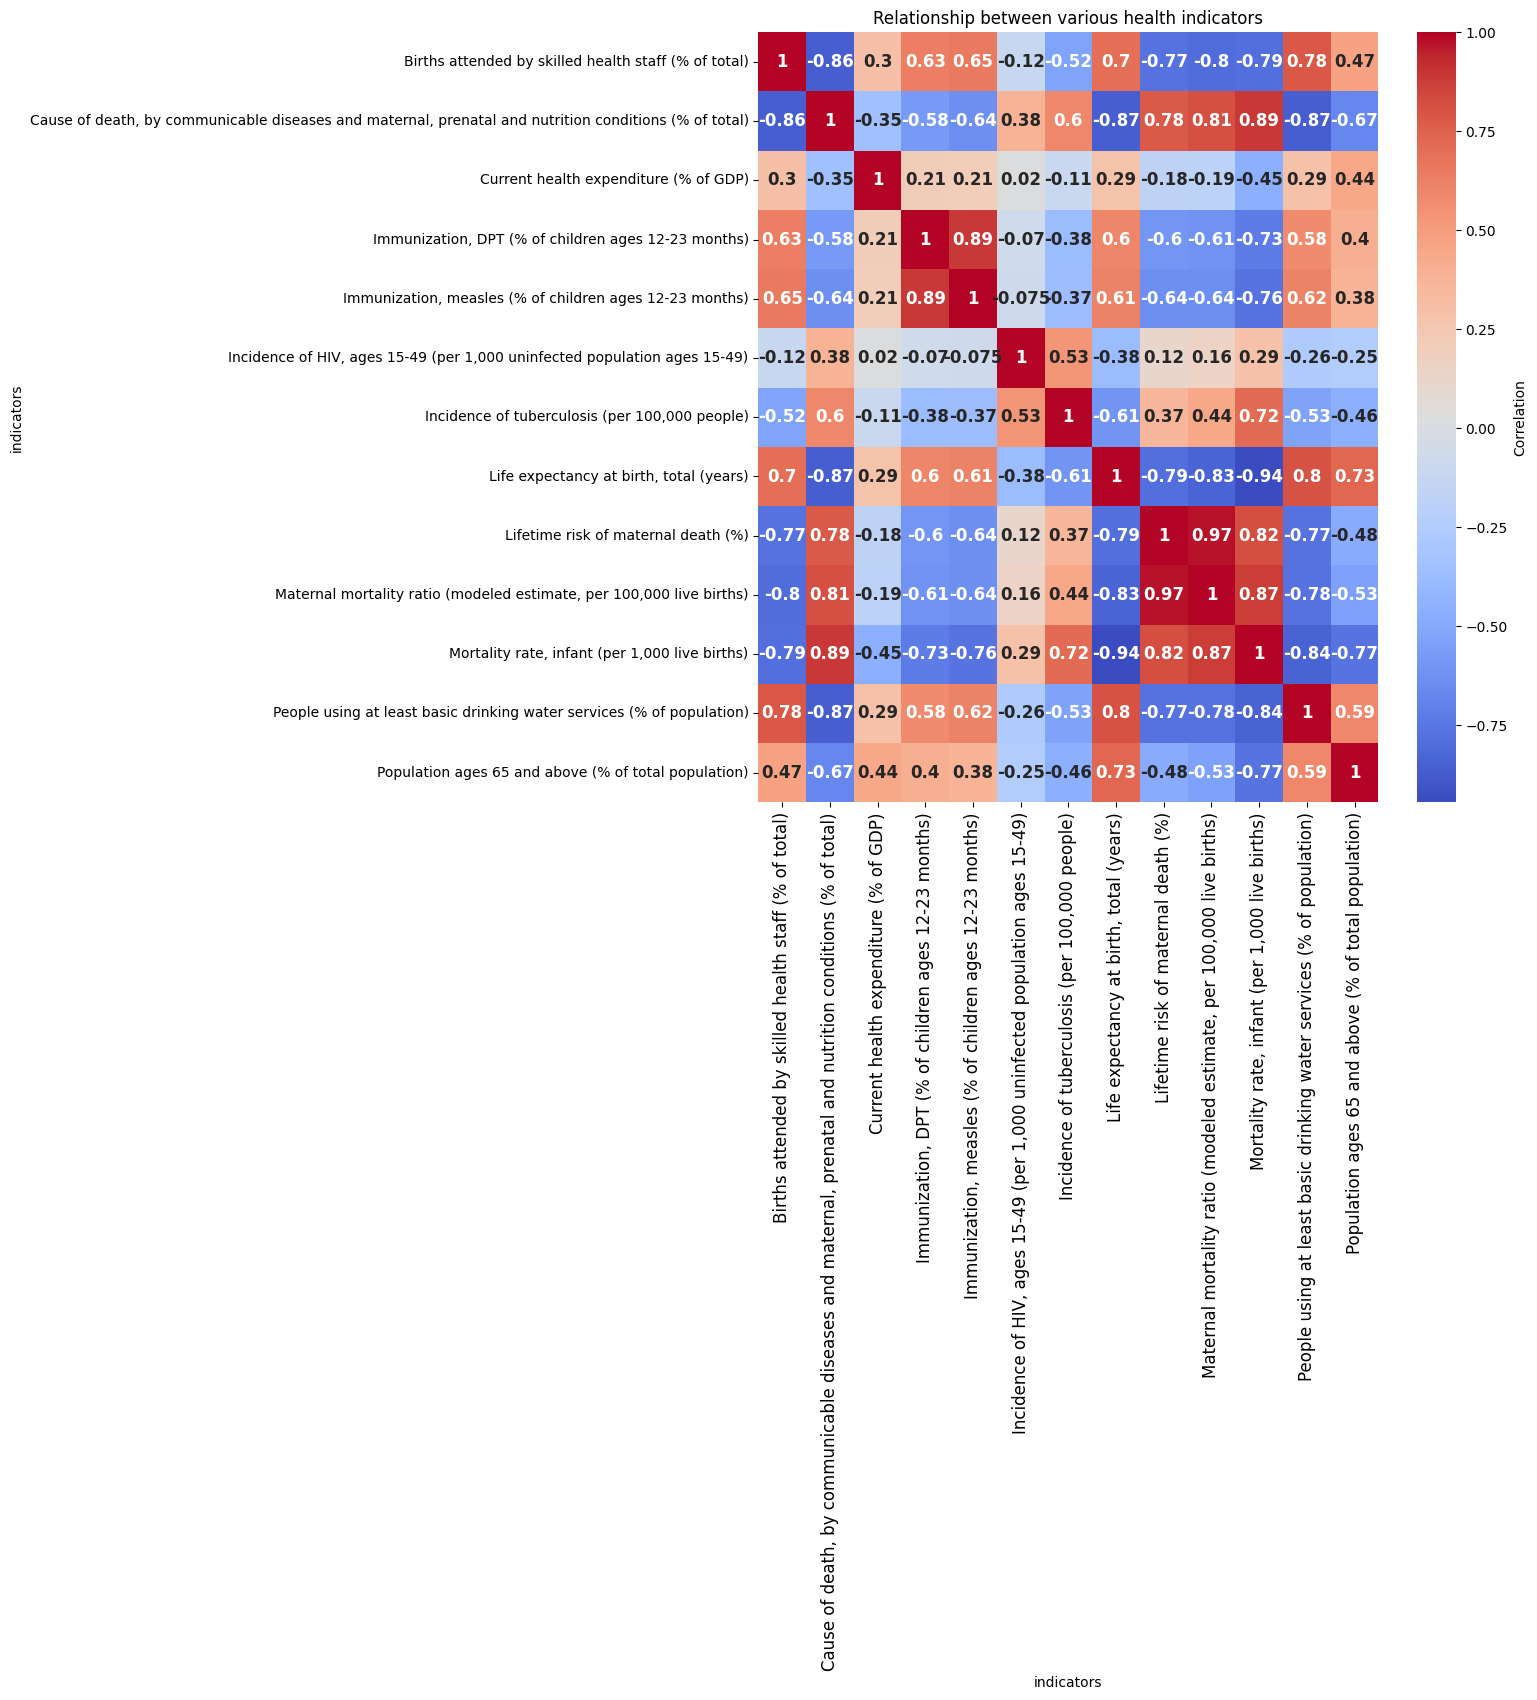

In [39]:
corr=df_wide.corr()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10 ), facecolor= "none")
ax = sns.heatmap(
    corr, 
    annot= True,
    cmap = "coolwarm",
    cbar_kws= {"label":"Correlation"},
    annot_kws= {"fontsize":12, "fontweight": "bold"}
)
plt.title("Relationship between various health indicators")

ax.tick_params(axis = "x", labelsize = 12)

In [45]:
df_pivot = health.pivot(index=["country","year"], columns= "indicators", values="value")
df_pivot

indicators        Births attended by skilled health staff (% of total)  \
country     year                                                         
Afghanistan 2016                                                NaN      
            2017                                               53.4      
            2018                                               58.8      
            2019                                                NaN      
            2020                                               61.8      
...                                                             ...      
Zimbabwe    2020                                                NaN      
            2021                                                NaN      
            2022                                                NaN      
            2023                                                NaN      
            2024                                                NaN      

indicators        Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)  \
country     year                                                                                                          
Afghanistan 2016                                                NaN                                                       
            2017                                                NaN                                                       
            2018                                                NaN                                                       
            2019                                          32.930451                                                       
            2020                                                NaN                                                       
...                                                             ...                                                       
Zimbabwe    2020                                                NaN                                                       
            2021                                                NaN                                                       
            2022                                                NaN                                                       
            2023                                                NaN                                                       
            2024                                                NaN                                                       

indicators        Current health expenditure (% of GDP)  \
country     year                                          
Afghanistan 2016                              11.818590   
            2017                              12.620817   
            2018                              14.208419   
            2019                              14.831320   
            2020                              15.533614   
...                                                 ...   
Zimbabwe    2020                               2.954401   
            2021                               2.671119   
            2022                               3.395195   
            2023                               2.926016   
            2024                                    NaN   

indicators        Immunization, DPT (% of children ages 12-23 months)  \
country     year                                                        
Afghanistan 2016                                               66.0     
            2017                                               64.0     
            2018                                               68.0     
            2019                                               65.0     
            2020                                               61.0     
...                                                             ...     
Zimbabwe    2020                                               86.0     
            

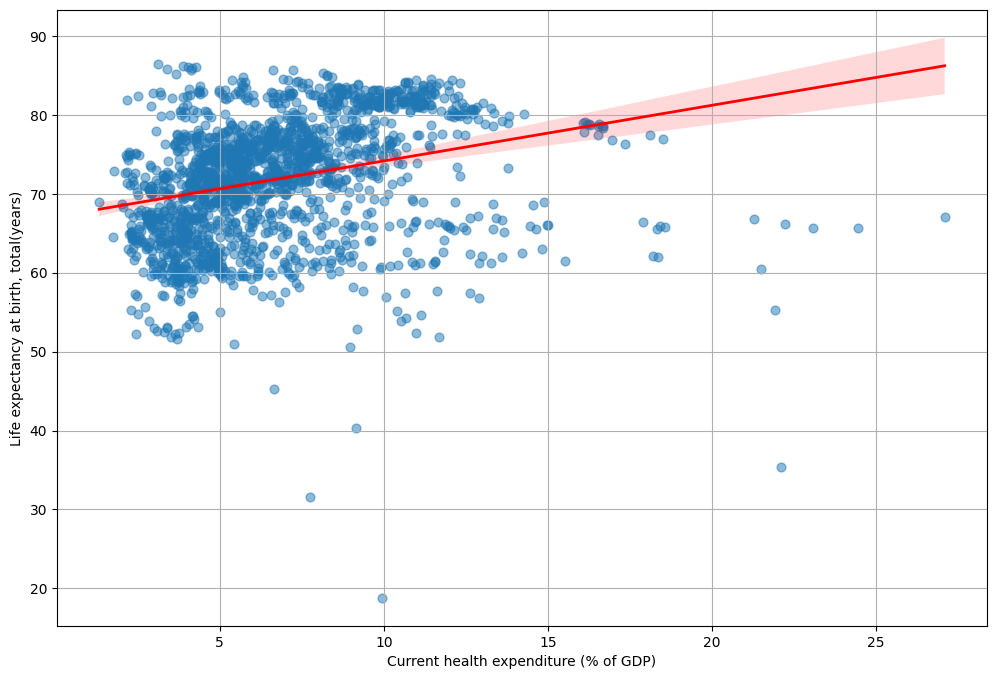

In [46]:
plt.figure(figsize=(12,8), facecolor="none")

ax= sns.regplot(data = df_pivot,
                x= "Current health expenditure (% of GDP)",
                y= "Life expectancy at birth, total (years)",
                scatter_kws= {"alpha": 0.5, "s": 40},
                line_kws={"color":"red", "lw":2}
                )
plt.xlabel("Current health expenditure (% of GDP)")
plt.ylabel("Life expectancy at birth, total(years)")
plt.grid(True)
plt.show()